<a href="https://colab.research.google.com/github/renzoardiles-pixel/Colab-UNI/blob/main/SQL/SESI%C3%93N_4_INTRODUCCI%C3%93N_A_FUNCIONES_(UDFS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

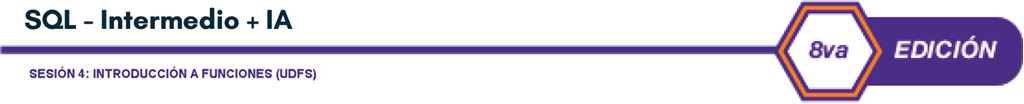

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Fundamentos de las Funciones</font>**

</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">¿Qué son las Funciones en SQL Server 2025?</font>**

</td>
</tr>
</table>

Las Funciones Creadas por el Usuario (UDF, por sus siglas en inglés) en T-SQL Server 2025 son un tipo de objeto de base de datos que permite a los usuarios encapsular y reutilizar lógica de programación en el servidor.

Estas funciones son definidas por el usuario y pueden realizar cálculos, manipular datos o devolver conjuntos de resultados, contribuyendo así a una mejor organización del código.

<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">Tipos principales de UDF</font>**

</td>
</tr>
</table>

>* **Funciones Escalares**
    * **Definición**: Devuelven un único valor.
    * **Uso**: Se pueden invocar en cualquier parte de una consulta SQL, como en la cláusula SELECT.
    * **Ejemplo**:



```
USE Northwind;
GO
CREATE OR ALTER FUNCTION dbo.ufn_categoria
(
	@CategoryID INT
)
RETURNS NVARCHAR(15)
AS
BEGIN
	/*
		Declaración de variable para almacenar
		el nombre de la categoría
	*/
	DECLARE @CategoryName NVARCHAR(15);

	SELECT @CategoryName = CategoryName
	FROM dbo.Categories
	WHERE CategoryID = @CategoryID;

	-- Retornar el nombre de la categoría
	RETURN @CategoryName;

END;
GO
-- Ejemplo de uso de la función ufn_categoria
SELECT dbo.ufn_categoria(2) AS CategoryName;
GO
```



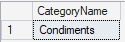

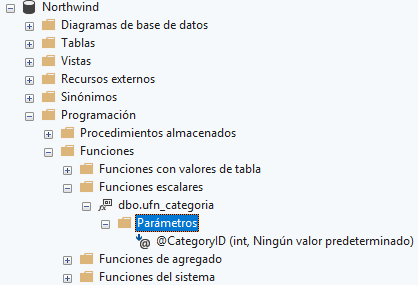

>* **Funciones de Tabla**
    * **Definición**: Devuelven un conjunto de resultados en forma de tabla.
    * **Uso**: Se pueden utilizar en la cláusula FROM de una consulta, como si fueran tablas.
    * **Ejemplo**:

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Función con valores de tabla insertados (Inline TVF)</font>**

</td>
</tr>
</table>



```
USE master
GO
SELECT
	xtype As Tipo,
	CASE xtype
		WHEN 'AF' THEN 'Función de agregado (CLR)'
		WHEN 'C' THEN 'Restricción CHECK'
		WHEN 'D' THEN 'Valor predeterminado o restricción DEFAULT'
		WHEN 'F' THEN 'Restricción FOREIGN KEY'
		WHEN 'L' THEN 'Registro'
		WHEN 'FN' THEN 'Función escalar'
		WHEN 'FS' THEN 'Función escalar del ensamblado (CLR)'
		WHEN 'FT' THEN 'Función con valores de tabla de ensamblado (CLR)'
		WHEN 'IF' THEN 'Función de tabla en línea'
		WHEN 'IT' THEN 'Tabla interna'
		WHEN 'P' THEN 'Procedimiento almacenado'
		WHEN 'PC' THEN 'Procedimiento almacenado del ensamblado (CLR)'
		WHEN 'PK' THEN 'Restricción PRIMARY KEY (de tipo K)'
		WHEN 'RF' THEN 'Procedimiento almacenado de filtro de replicación'
		WHEN 'S' THEN 'Tabla del sistema'
		WHEN 'SN' THEN 'Sinónimo'
		WHEN 'SO' THEN 'Secuencia'
		WHEN 'SQ' THEN 'Cola de servicio'
		WHEN 'TA' THEN 'Desencadenador DML del ensamblado (CLR)'
		WHEN 'TF' THEN 'Función de tabla'
		WHEN 'TR' THEN 'Desencadenador DML de SQL'
		WHEN 'TT' THEN 'Tipo de tabla'
		WHEN 'U' THEN 'Tabla de usuario'
		WHEN 'UQ' THEN 'Restricción UNIQUE (de tipo K)'
		WHEN 'V' THEN 'Vista'
		WHEN 'X' THEN 'Procedimiento almacenado extendido'
		ELSE 'Otros'
	END AS Descripción,
	COUNT(*) AS Total
FROM sysobjects
GROUP BY xtype
ORDER BY 3 DESC;
GO
```





```
-- ================================================
-- Template generated from Template Explorer using:
-- Create Inline Function (New Menu).SQL
--
-- Use the Specify Values for Template Parameters
-- command (Ctrl-Shift-M) to fill in the parameter
-- values below.
--
-- This block of comments will not be included in
-- the definition of the function.
-- ================================================
SET ANSI_NULLS ON
GO
SET QUOTED_IDENTIFIER ON
GO
-- =============================================
-- Author:		Edgard Lucho
-- Create date: 09/02/2025
-- Description:	Función de tabla para obtener el
--              listado de productos por categoría.
-- =============================================
CREATE OR ALTER FUNCTION uif_productos_x_categoría
(
	-- Parámetro para el código de la categoría
	@CategoryID int
)
RETURNS TABLE
AS
RETURN
(
	SELECT
		[ProductID]
		,[ProductName]
		,[SupplierID]
		,[CategoryID]
		,dbo.ufn_categoria([CategoryID]) AS Categoría
		,[QuantityPerUnit]
		,[UnitPrice]
		,[UnitsInStock]
		,[UnitsOnOrder]
		,[ReorderLevel]
		,[Discontinued]
	FROM [dbo].[Products]
	WHERE [CategoryID] = @CategoryID
)
GO
SELECT *
FROM dbo.uif_productos_x_categoría(2);
GO
```



<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Función con valores de tabla de múltiples instrucciones - MSTVF</font>**

</td>
</tr>
</table>



```
-- ================================================
-- Template generated from Template Explorer using:
-- Create Multi-Statement Function (New Menu).SQL
--
-- Use the Specify Values for Template Parameters
-- command (Ctrl-Shift-M) to fill in the parameter
-- values below.
--
-- This block of comments will not be included in
-- the definition of the function.
-- ================================================
SET ANSI_NULLS ON
GO
SET QUOTED_IDENTIFIER ON
GO
-- =============================================
--                Author: Edgard Lucho
--     Fecha de creación: 09/02/2026
-- Fecha de modificación: 09/02/2026
--           Description: Función de tabla para obtener el
--                        listado de productos por categoría.
-- =============================================
CREATE OR ALTER FUNCTION utf_productos_x_categoria
(
	@CategoryID int
)
RETURNS
@T TABLE
(
	[ProductID] [int] NOT NULL,
	[ProductName] [nvarchar](40) NOT NULL,
	[SupplierID] [int] NULL,
	[CategoryID] [int] NULL,
	[Categoría] [nvarchar](15) NULL,
	[QuantityPerUnit] [nvarchar](20) NULL,
	[UnitPrice] [money] NULL,
	[UnitsInStock] [smallint] NULL,
	[UnitsOnOrder] [smallint] NULL,
	[ReorderLevel] [smallint] NULL,
	[Discontinued] [bit] NOT NULL
)
AS
BEGIN
	INSERT INTO @T
	(
		[ProductID]
		,[ProductName]
		,[SupplierID]
		,[CategoryID]
		,[Categoría]
		,[QuantityPerUnit]
		,[UnitPrice]
		,[UnitsInStock]
		,[UnitsOnOrder]
		,[ReorderLevel]
		,[Discontinued]
	)
	SELECT
		[ProductID]
		,[ProductName]
		,[SupplierID]
		,[CategoryID]
		,dbo.ufn_categoria([CategoryID]) AS Categoría
		,[QuantityPerUnit]
		,[UnitPrice]
		,[UnitsInStock]
		,[UnitsOnOrder]
		,[ReorderLevel]
		,[Discontinued]
	FROM [dbo].[Products]
	WHERE [CategoryID] = @CategoryID;

	RETURN
END
GO
SELECT *
FROM utf_productos_x_categoria(1);
GO
```



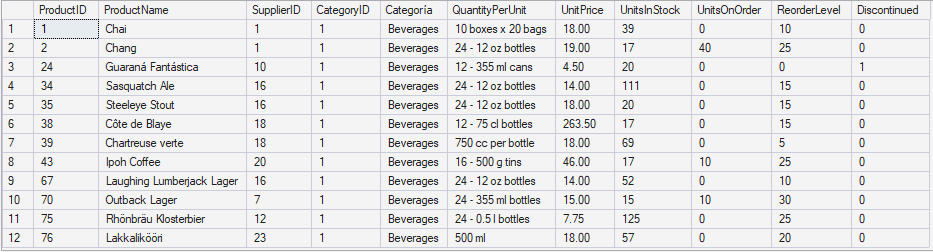

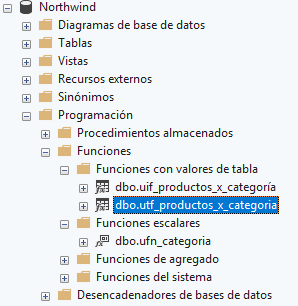

<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">Diferencia entre Stored Procedures, Vistas y Funciones</font>**

</td>
</tr>
</table>

| Característica            | Stored Procedures                                | Vistas                                             | Funciones                                      |
|---------------------------|--------------------------------------------------|---------------------------------------------------|------------------------------------------------|
| **Definición**            | Colección de instrucciones SQL que se pueden ejecutar. | Consulta que presenta datos de una o más tablas.   | Bloque de código que realiza cálculos o retorna valores. |
| **Valor de Retorno**      | No devuelve un valor, puede retornar múltiples conjuntos de resultados. | No devuelve un valor, solo presenta datos.          | Devuelve un solo valor (Escalar) o un conjunto de resultados (Tabla). |
| **Invocación**            | Se ejecuta usando `EXECUTE` o `EXEC`.          | Se usa en consultas como una tabla.                | Se puede usar directamente en expresiones SQL.  |
| **Parámetros**            | Puede aceptar parámetros de entrada y de salida. | No acepta parámetros.                               | Solo acepta parámetros de entrada.                |
| **Efecto en la Base de Datos** | Puede modificar datos (INSERT, UPDATE, DELETE). | No modifica datos, solo los presenta.              | No puede modificar datos.                         |
| **Control de Transacciones** | Puede gestionar transacciones.                  | No puede gestionar transacciones.                   | No puede gestionar transacciones.                |
| **Usabilidad**            | Preferidas para tareas complejas y de lógica.   | Útiles para abstraer complejidades de consultas.   | Utilizadas para cálculos o formatos reutilizables. |
| **Ámbito**                | Se crean bajo un usuario específico o en la base de datos. | Se definen en el contexto de la base de datos.     | Se crea en el contexto de la base de datos.      |


<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">Creación de Funciones Escalares (Scalar UDFs)</font>**

</td>
</tr>
</table>



```
USE Northwind;
GO
CREATE FUNCTION dbo.ufn_categoria
(
    @CategoryID INT
)
RETURNS NVARCHAR(15)
AS
BEGIN
    /*
        Declaración de variable para almacenar
        el nombre de la categoría
    */
    DECLARE @CategoryName NVARCHAR(15);

    SELECT @CategoryName = CategoryName
    FROM dbo.Categories
    WHERE CategoryID = @CategoryID;
    
    -- Retornar el nombre de la categoría
    RETURN @CategoryName;

END;
GO
-- Ejemplo de uso de la función ufn_categoria
SELECT dbo.ufn_categoria(2) AS CategoryName;
GO
```



<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">Modificación de Funciones Escalares (Scalar UDFs)</font>**

</td>
</tr>
</table>



```
USE Northwind;
GO
ALTER FUNCTION dbo.ufn_categoria
(
    @CategoryID INT
)
RETURNS NVARCHAR(15)
AS
BEGIN
    /*
        Declaración de variable para almacenar
        el nombre de la categoría
    */
    DECLARE @CategoryName NVARCHAR(15);

    SELECT @CategoryName = CategoryName
    FROM dbo.Categories
    WHERE CategoryID = @CategoryID;
    
    -- Retornar el nombre de la categoría
    RETURN @CategoryName;

END;
GO
-- Ejemplo de uso de la función ufn_categoria
SELECT dbo.ufn_categoria(2) AS CategoryName;
GO
```



<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">Eliminación de Funciones Escalares (Scalar UDFs)</font>**

</td>
</tr>
</table>



```
USE Northwind;
GO
IF EXISTS
(
	SELECT name
	FROM sysobjects
	WHERE
			xtype = 'FN'
		AND
			name = 'ufn_categoria'
)
DROP FUNCTION ufn_categoria;
GO
```



<table width='99%'>
<tr>
<td bgcolor='#D47031'>

## **<font color="#FFFFFF">Práctica con IA</font>**

</td>
</tr>
</table>

In [ ]:
```sql
USE Northwind;
GO

CREATE OR ALTER FUNCTION dbo.ufn_nombre_completo
(
    @EmployeeID INT
)
RETURNS NVARCHAR(MAX)
AS
BEGIN
    DECLARE @FullName NVARCHAR(MAX);

    SELECT @FullName =
        ISNULL(TitleOfCourtesy + ' ', '') + -- Add space only if TitleOfCourtesy is not NULL
        ISNULL(FirstName, '') + ' ' +       -- Add space after FirstName
        ISNULL(LastName, '')
    FROM dbo.Employees
    WHERE EmployeeID = @EmployeeID;

    RETURN @FullName;
END;
GO

-- Ejemplo de uso de la función ufn_nombre_completo
SELECT
    EmployeeID,
    FirstName,
    LastName,
    TitleOfCourtesy,
    dbo.ufn_nombre_completo(EmployeeID) AS FullName
FROM
    dbo.Employees
WHERE EmployeeID = 1;
GO
```

```markdown
**Explicación:**

1.  **`USE Northwind;`**: Asegura que la función se cree en la base de datos `Northwind`.
2.  **`CREATE OR ALTER FUNCTION dbo.ufn_nombre_completo (@EmployeeID INT)`**: Define una función escalar llamada `ufn_nombre_completo` en el esquema `dbo`. Toma un parámetro `@EmployeeID` de tipo `INT`.
3.  **`RETURNS NVARCHAR(MAX)`**: Indica que la función devolverá un valor de tipo cadena de longitud variable y máxima.
4.  **`DECLARE @FullName NVARCHAR(MAX);`**: Declara una variable local para almacenar el nombre completo concatenado.
5.  **`SELECT @FullName = ISNULL(TitleOfCourtesy + ' ', '') + ISNULL(FirstName, '') + ' ' + ISNULL(LastName, '')`**: Recupera los campos `TitleOfCourtesy`, `FirstName` y `LastName` para el `EmployeeID` especificado y los concatena.
    *   `ISNULL(TitleOfCourtesy + ' ', '')`: Si `TitleOfCourtesy` no es `NULL`, añade el título seguido de un espacio; de lo contrario, devuelve una cadena vacía. Esto evita `NULL` en la concatenación.
    *   `ISNULL(FirstName, '')`: Si `FirstName` no es `NULL`, lo usa; de lo contrario, devuelve una cadena vacía.
    *   `' ' + ISNULL(LastName, '')`: Añade un espacio antes del `LastName` y maneja `NULL` para `LastName` de manera similar.
6.  **`RETURN @FullName;`**: Devuelve el nombre completo resultante.
7.  **`SELECT ... dbo.ufn_nombre_completo(EmployeeID) AS FullName ...`**: Este es un ejemplo de cómo puedes usar la función en una consulta `SELECT` para obtener el nombre completo de los empleados.
```



```
/* Created by GitHub Copilot in SSMS - review carefully before executing */
/*
  Función escalar: devuelve el nombre completo del empleado combinando
  TitleOfCourtesy, FirstName y LastName. Omite valores NULL o cadenas vacías
  y normaliza los espacios entre partes del nombre.
*/
-- Crea o altera la función scalar que concatena los componentes del nombre
CREATE OR ALTER FUNCTION dbo.ufn_nombre_completo
(
    @EmployeeID INT
)
RETURNS NVARCHAR(60)
AS
BEGIN
    DECLARE @FullName NVARCHAR(100);

    SELECT @FullName =
    TRIM
    (
        CONCAT_WS
        (
            ' ',
            NULLIF(TitleOfCourtesy, ''),
            NULLIF(FirstName, ''),
            NULLIF(LastName, '')
        )
    )
    FROM dbo.Employees
    WHERE EmployeeID = @EmployeeID;

    RETURN @FullName;
END;
GO
SELECT
    EmployeeID,
    TitleOfCourtesy,
    FirstName,
    LastName,
    dbo.ufn_nombre_completo(EmployeeID) AS FullName
FROM dbo.Employees;
GO
```



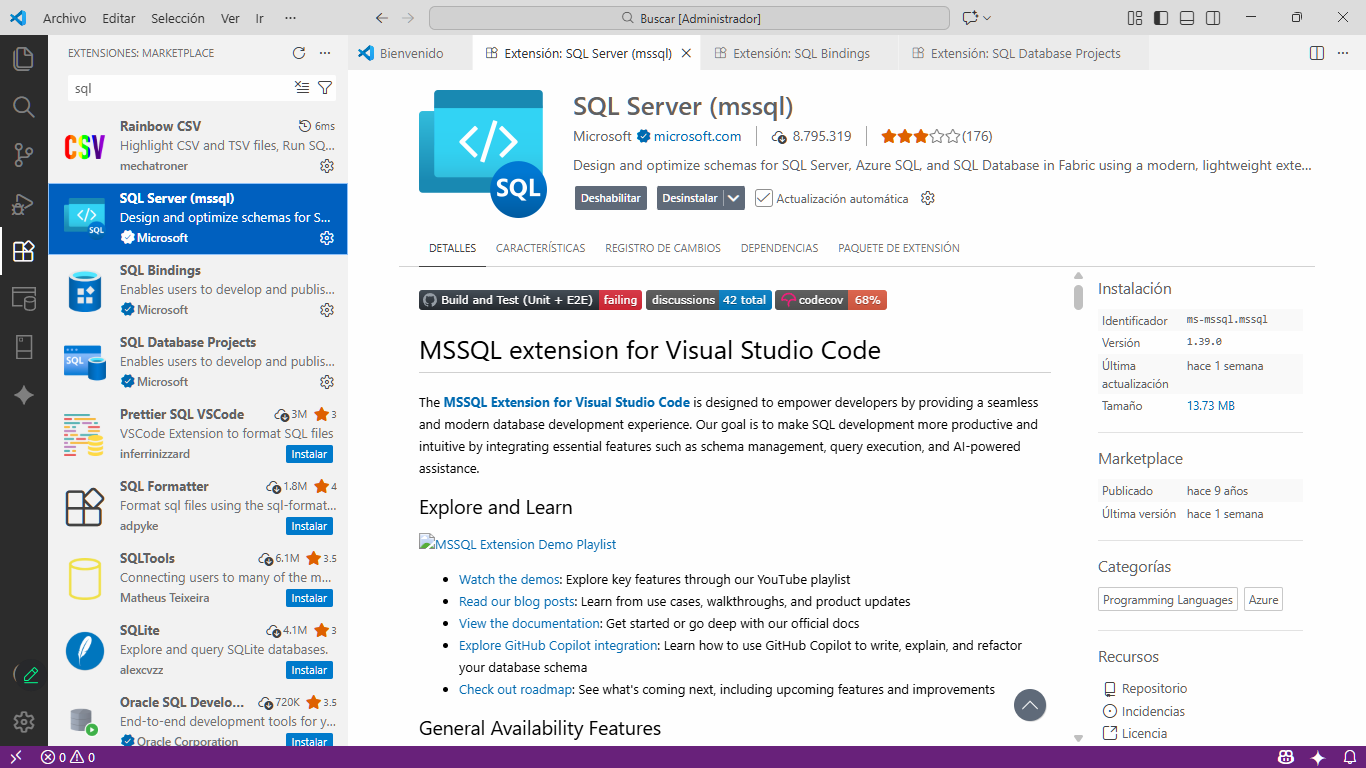

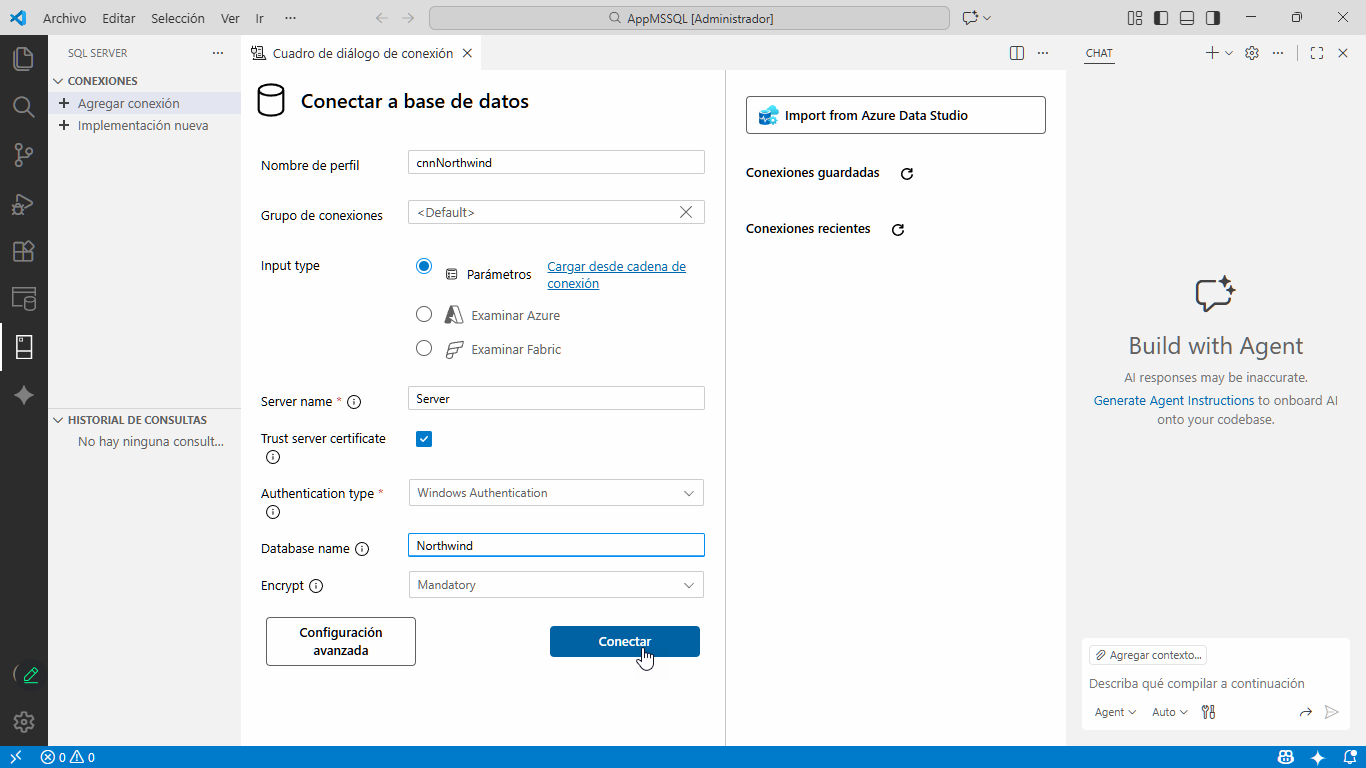



```
He creado la función ufn_categoria. Crear ufn_proveedor que ingrese como parametro el código del proveedor
```





```
SET ANSI_NULLS ON
GO
SET QUOTED_IDENTIFIER ON
GO
CREATE OR ALTER FUNCTION [dbo].[ufn_proveedor]
(
    @SupplierID INT
)
RETURNS NVARCHAR(40)
AS
BEGIN
    /*
        Declaración de variable para almacenar
        el nombre del proveedor
    */
    DECLARE @SupplierName NVARCHAR(40);

    SELECT @SupplierName = CompanyName
    FROM dbo.Suppliers
    WHERE SupplierID = @SupplierID;
    
    -- Retornar el nombre del proveedor
    RETURN @SupplierName;

END;
GO
SELECT dbo.ufn_proveedor(1) AS Proveedor1,
       dbo.ufn_proveedor(2) AS Proveedor2,
       dbo.ufn_proveedor(3) AS Proveedor3;
GO
```





```
Crear una función escalar que permita ingresar como parámetro un número entero desde 0 hasta 9999 y me devuelva dicho número en palbras en español. Ejemplo SELECT dbo.ufn_num_pal(12) y me debe devolver El número 12 en palabras es DOCE
```





```
SET ANSI_NULLS ON
GO
SET QUOTED_IDENTIFIER ON
GO
CREATE OR ALTER FUNCTION dbo.ufn_num_pal
(
    @number INT
)
RETURNS NVARCHAR(MAX)
AS
BEGIN
    
    DECLARE @result NVARCHAR(MAX) = '';
    DECLARE @units TABLE (id INT, word NVARCHAR(20));
    DECLARE @tens TABLE (id INT, word NVARCHAR(20));
    DECLARE @hundreds TABLE (id INT, word NVARCHAR(20));

    INSERT INTO @units VALUES
        (0, ''), (1, 'UNO'), (2, 'DOS'), (3, 'TRES'), (4, 'CUATRO'),
        (5, 'CINCO'), (6, 'SEIS'), (7, 'SIETE'), (8, 'OCHO'), (9, 'NUEVE');

    INSERT INTO @tens VALUES
        (10, 'DIEZ'), (11, 'ONCE'), (12, 'DOCE'), (13, 'TRECE'), (14, 'CATORCE'),
        (15, 'QUINCE'), (16, 'DIECISÉIS'), (17, 'DIECISIETE'), (18, 'DIECIOCHO'), (19, 'DIECINUEVE'),
        (20, 'VEINTE'), (21, 'VEINTIUNO'), (22, 'VEINTIDÓS'), (23, 'VEINTITRÉS'), (24, 'VEINTICUATRO'),
        (25, 'VEINTICINCO'), (26, 'VEINTISÉIS'), (27, 'VEINTISIETE'), (28, 'VEINTIOCHO'), (29, 'VEINTINUEVE'),
        (30, 'TREINTA'), (40, 'CUARENTA'), (50, 'CINCUENTA'), (60, 'SESENTA'), (70, 'SETENTA'),
        (80, 'OCHENTA'), (90, 'NOVENTA');

    INSERT INTO @hundreds VALUES
        (100, 'CIEN'), (200, 'DOSCIENTOS'), (300, 'TRESCIENTOS'), (400, 'CUATROCIENTOS'),
        (500, 'QUINIENTOS'), (600, 'SEISCIENTOS'), (700, 'SETECIENTOS'), (800, 'OCHOCIENTOS'), (900, 'NOVECIENTOS');

    IF @number < 0 OR @number > 9999
    BEGIN
        SET @result = 'NÚMERO FUERA DE RANGO';
    END
    ELSE IF @number = 0 OR @number = 1
    BEGIN
        SET @result = IIF(@number=0, 'CERO', 'UNO');
    END
    ELSE
    BEGIN
        DECLARE @thousands INT = @number / 1000;
        DECLARE @remainder INT = @number % 1000;

        IF @thousands > 0
        BEGIN
            IF @thousands = 1
                SET @result = 'MIL';
            ELSE
                SELECT @result = T2.word + ' MIL' FROM @units T2 WHERE T2.id = @thousands;
        END

        IF @remainder > 0
        BEGIN
            DECLARE @hundreds_val INT = @remainder / 100;
            DECLARE @tens_units_val INT = @remainder % 100;
            DECLARE @temp_hundreds_word NVARCHAR(20);

            IF @hundreds_val > 0
            BEGIN
                IF @hundreds_val = 1 AND @tens_units_val > 0
                    SET @temp_hundreds_word = 'CIENTO';
                ELSE
                    SELECT @temp_hundreds_word = T3.word FROM @hundreds T3 WHERE T3.id = @hundreds_val * 100;

                SET @result = LTRIM(RTRIM(@result + ' ' + @temp_hundreds_word));
            END

            IF @tens_units_val > 0
            BEGIN
                DECLARE @temp_tens_word NVARCHAR(20);
                IF @tens_units_val <= 29
                BEGIN
                    SELECT @temp_tens_word = T2.word FROM @tens T2 WHERE T2.id = @tens_units_val;
                END
                ELSE
                BEGIN
                    DECLARE @tens_val INT = (@tens_units_val / 10) * 10;
                    DECLARE @units_val INT = @tens_units_val % 10;

                    SELECT @temp_tens_word = T2.word FROM @tens T2 WHERE T2.id = @tens_val;
                    IF @units_val > 0
                    BEGIN
                        SELECT @temp_tens_word = @temp_tens_word + ' Y ' + T1.word FROM @units T1 WHERE T1.id = @units_val;
                    END
                END
                SET @result = LTRIM(RTRIM(@result + ' ' + @temp_tens_word));
            END
        END
    END
    SET @result = 'EL NÚMERO ' + CAST(@number AS NVARCHAR(10)) + ' EN PALABRAS ES ' + @result;
    RETURN @result;
END;
GO
SET NOCOUNT ON;
-- Ejemplos de uso de la función ufn_num_pal
SELECT dbo.ufn_num_pal(0) AS Number0;
SELECT dbo.ufn_num_pal(1) AS Number1;
SELECT dbo.ufn_num_pal(12) AS Number12;
SELECT dbo.ufn_num_pal(20) AS Number20;
SELECT dbo.ufn_num_pal(21) AS Number21;
SELECT dbo.ufn_num_pal(22) AS Number22;
SELECT dbo.ufn_num_pal(23) AS Number23;
SELECT dbo.ufn_num_pal(26) AS Number26;
SELECT dbo.ufn_num_pal(30) AS Number30;
SELECT dbo.ufn_num_pal(31) AS Number31;
SELECT dbo.ufn_num_pal(100) AS Number100;
SELECT dbo.ufn_num_pal(123) AS Number123;
SELECT dbo.ufn_num_pal(500) AS Number500;
SELECT dbo.ufn_num_pal(999) AS Number999;
SELECT dbo.ufn_num_pal(1000) AS Number1000;
SELECT dbo.ufn_num_pal(2025) AS Number2025;
SELECT dbo.ufn_num_pal(9999) AS Number9999;


```





```
/* Created by GitHub Copilot in SSMS - review carefully before executing */
/*
  Función escalar: convierte un entero (0..9999) a palabras en español
  y devuelve la frase: "El número <n> en palabras es <TEXTO>".
*/
CREATE OR ALTER FUNCTION dbo.ufn_num_pal(@num INT)
RETURNS NVARCHAR(200)
AS
BEGIN
    DECLARE @n INT = ISNULL(@num, 0);

    IF @n < 0 OR @n > 9999
        RETURN N'Número fuera de rango. Introduzca un entero entre 0 y 9999.';

    DECLARE @th INT = @n / 1000;             -- miles
    DECLARE @hd INT = (@n % 1000) / 100;     -- centenas
    DECLARE @tu INT = @n % 100;              -- decenas y unidades
    DECLARE @u INT = @tu % 10;               -- unidades

    DECLARE @word_th NVARCHAR(50) = N'';
    DECLARE @word_hd NVARCHAR(50) = N'';
    DECLARE @word_tu NVARCHAR(100) = N'';

    DECLARE @units TABLE (v INT PRIMARY KEY, w NVARCHAR(20));
    INSERT INTO @units(v,w) VALUES
    --(0,N'CERO'),
    (1,N'UNO'),(2,N'DOS'),(3,N'TRES'),(4,N'CUATRO'),(5,N'CINCO'),(6,N'SEIS'),(7,N'SIETE'),(8,N'OCHO'),(9,N'NUEVE'),
    (10,N'DIEZ'),(11,N'ONCE'),(12,N'DOCE'),(13,N'TRECE'),(14,N'CATORCE'),(15,N'QUINCE'),(16,N'DIECISÉIS'),(17,N'DIECISIETE'),(18,N'DIECIOCHO'),(19,N'DIECINUEVE'),
    (20,N'VEINTE'),(21,N'VEINTIUNO'),(22,N'VEINTIDÓS'),(23,N'VEINTITRÉS'),(24,N'VEINTICUATRO'),(25,N'VEINTICINCO'),(26,N'VEINTISÉIS'),(27,N'VEINTISIETE'),(28,N'VEINTIOCHO'),(29,N'VEINTINUEVE');

    -- miles
    IF @th >= 1
    BEGIN
        IF @th = 1 SET @word_th = N'MIL';
        ELSE
            SELECT @word_th = w + N' MIL' FROM @units WHERE v = @th;
    END

    -- centenas
    IF @hd > 0
    BEGIN
        SET @word_hd = CASE @hd
            WHEN 1 THEN CASE WHEN @tu = 0 THEN N'CIEN' ELSE N'CIENTO' END
            WHEN 2 THEN N'DOSCIENTOS'
            WHEN 3 THEN N'TRESCIENTOS'
            WHEN 4 THEN N'CUATROCIENTOS'
            WHEN 5 THEN N'QUINIENTOS'
            WHEN 6 THEN N'SEISCIENTOS'
            WHEN 7 THEN N'SETECIENTOS'
            WHEN 8 THEN N'OCHOCIENTOS'
            WHEN 9 THEN N'NOVECIENTOS'
            ELSE N'' END;
    END

    -- decenas y unidades
    IF @tu BETWEEN 0 AND 29
    BEGIN
        SELECT @word_tu = w FROM @units WHERE v = @tu;
    END
    /*
    ELSE IF @tu BETWEEN 20 AND 29
    BEGIN
        IF @tu = 20 SET @word_tu = N'VEINTE';
        ELSE
            SELECT @word_tu = N'VEINTI' + LOWER(w) FROM @units WHERE v = @u;
        SET @word_tu = UPPER(@word_tu);
    END
    */
    ELSE
    BEGIN
        DECLARE @tens INT = @tu / 10;
        DECLARE @tensword NVARCHAR(20) = CASE @tens
            WHEN 3 THEN N'TREINTA' WHEN 4 THEN N'CUARENTA' WHEN 5 THEN N'CINCUENTA' WHEN 6 THEN N'SESENTA'
            WHEN 7 THEN N'SETENTA' WHEN 8 THEN N'OCHENTA' WHEN 9 THEN N'NOVENTA' ELSE N'' END;
        IF @u = 0 SET @word_tu = @tensword;
        ELSE
            SELECT @word_tu = @tensword + N' Y ' + w FROM @units WHERE v = @u;
    END

    DECLARE @parts NVARCHAR(200) = CONCAT_WS(N' ', NULLIF(@word_th,N''), NULLIF(@word_hd,N''), NULLIF(@word_tu,N''));

    IF @n = 0 SET @parts = N'CERO';

    RETURN N'El número ' + CAST(@n AS NVARCHAR(10)) + N' en palabras es ' + @parts;
END;
GO
SET NOCOUNT ON;
-- Ejemplos de uso de la función ufn_num_pal
SELECT dbo.ufn_num_pal(0) AS Number0;
SELECT dbo.ufn_num_pal(1) AS Number1;
SELECT dbo.ufn_num_pal(12) AS Number12;
SELECT dbo.ufn_num_pal(20) AS Number20;
SELECT dbo.ufn_num_pal(21) AS Number21;
SELECT dbo.ufn_num_pal(22) AS Number22;
SELECT dbo.ufn_num_pal(23) AS Number23;
SELECT dbo.ufn_num_pal(26) AS Number26;
SELECT dbo.ufn_num_pal(30) AS Number30;
SELECT dbo.ufn_num_pal(31) AS Number31;
SELECT dbo.ufn_num_pal(100) AS Number100;
SELECT dbo.ufn_num_pal(123) AS Number123;
SELECT dbo.ufn_num_pal(500) AS Number500;
SELECT dbo.ufn_num_pal(999) AS Number999;
SELECT dbo.ufn_num_pal(1000) AS Number1000;
SELECT dbo.ufn_num_pal(2025) AS Number2025;
SELECT dbo.ufn_num_pal(9999) AS Number9999;
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#B00A0F'>

# **<font color="#FFFFFF"> Entenderlo y modificarlo para que los textos salga con acentos</font>**
</td>
</tr>
</table>



```
SET ANSI_NULLS ON
GO
SET QUOTED_IDENTIFIER ON
GO
CREATE OR ALTER FUNCTION [dbo].[ufn_num_pal]
(
    @Numero INT
)
RETURNS NVARCHAR(200)
AS
BEGIN
    /*
        Función que convierte números enteros (0-9999)
        a palabras en español
    */
    DECLARE @Resultado NVARCHAR(200);
    DECLARE @Unidades NVARCHAR(50);
    DECLARE @Decenas NVARCHAR(50);
    DECLARE @Centenas NVARCHAR(50);
    DECLARE @Miles NVARCHAR(50);
    DECLARE @NumUnidades INT;
    DECLARE @NumDecenas INT;
    DECLARE @NumCentenas INT;
    DECLARE @NumMiles INT;

    -- Validar rango
    IF @Numero < 0 OR @Numero > 9999
        RETURN 'Número fuera de rango (0-9999)';

    SET @NumUnidades = @Numero % 10;
    SET @NumDecenas = (@Numero / 10) % 10;
    SET @NumCentenas = (@Numero / 100) % 10;
    SET @NumMiles = @Numero / 1000;

    -- Obtener palabras de unidades
    SET @Unidades = CASE @NumUnidades
        WHEN 0 THEN ''
        WHEN 1 THEN 'UNO'
        WHEN 2 THEN 'DOS'
        WHEN 3 THEN 'TRES'
        WHEN 4 THEN 'CUATRO'
        WHEN 5 THEN 'CINCO'
        WHEN 6 THEN 'SEIS'
        WHEN 7 THEN 'SIETE'
        WHEN 8 THEN 'OCHO'
        WHEN 9 THEN 'NUEVE'
    END;

    -- Obtener palabras de decenas
    SET @Decenas = CASE @NumDecenas
        WHEN 0 THEN ''
        WHEN 1 THEN CASE @NumUnidades
            WHEN 0 THEN 'DIEZ'
            WHEN 1 THEN 'ONCE'
            WHEN 2 THEN 'DOCE'
            WHEN 3 THEN 'TRECE'
            WHEN 4 THEN 'CATORCE'
            WHEN 5 THEN 'QUINCE'
            ELSE 'DIECI' + @Unidades
        END
        WHEN 2 THEN CASE WHEN @NumUnidades = 0 THEN 'VEINTE' ELSE 'VEINTIUNO' END
        WHEN 3 THEN 'TREINTA'
        WHEN 4 THEN 'CUARENTA'
        WHEN 5 THEN 'CINCUENTA'
        WHEN 6 THEN 'SESENTA'
        WHEN 7 THEN 'SETENTA'
        WHEN 8 THEN 'OCHENTA'
        WHEN 9 THEN 'NOVENTA'
    END;

    -- Obtener palabras de centenas
    SET @Centenas = CASE @NumCentenas
        WHEN 0 THEN ''
        WHEN 1 THEN 'CIENTO'
        WHEN 2 THEN 'DOSCIENTOS'
        WHEN 3 THEN 'TRESCIENTOS'
        WHEN 4 THEN 'CUATROCIENTOS'
        WHEN 5 THEN 'QUINIENTOS'
        WHEN 6 THEN 'SEISCIENTOS'
        WHEN 7 THEN 'SETECIENTOS'
        WHEN 8 THEN 'OCHOCIENTOS'
        WHEN 9 THEN 'NOVECIENTOS'
    END;

    -- Ajustar "CIENTO" a "CIEN" cuando es exactamente 100
    IF @Numero = 100
        SET @Centenas = 'CIEN';

    -- Obtener palabras de miles
    SET @Miles = CASE @NumMiles
        WHEN 0 THEN ''
        WHEN 1 THEN 'MIL'
        WHEN 2 THEN 'DOS MIL'
        WHEN 3 THEN 'TRES MIL'
        WHEN 4 THEN 'CUATRO MIL'
        WHEN 5 THEN 'CINCO MIL'
        WHEN 6 THEN 'SEIS MIL'
        WHEN 7 THEN 'SIETE MIL'
        WHEN 8 THEN 'OCHO MIL'
        WHEN 9 THEN 'NUEVE MIL'
    END;

    -- Construir resultado manejando casos especiales
    SET @Resultado = '';
    
    IF @NumMiles > 0
        SET @Resultado = @Miles + ' ';
    
    IF @NumCentenas > 0
        SET @Resultado = @Resultado + @Centenas + ' ';
    
    -- Manejo especial para decenas
    IF @NumDecenas = 1
    BEGIN
        SET @Resultado = @Resultado + @Decenas;
        SET @Unidades = '';
    END
    ELSE IF @NumDecenas > 1
    BEGIN
        SET @Resultado = @Resultado + @Decenas;
        IF @NumUnidades > 0
            SET @Resultado = @Resultado + ' Y ' + @Unidades;
    END
    ELSE IF @NumUnidades > 0
    BEGIN
        SET @Resultado = @Resultado + @Unidades;
    END
    ELSE IF @Numero = 0
    BEGIN
        SET @Resultado = 'CERO';
    END;

    -- Limpiar espacios en blanco
    SET @Resultado = LTRIM(RTRIM(@Resultado));

    RETURN 'El número ' + CAST(@Numero AS NVARCHAR(10)) + ' en palabras es ' + @Resultado;

END;
GO
SET NOCOUNT ON;
-- Ejemplos de uso de la función ufn_num_pal
SELECT dbo.ufn_num_pal(0) AS Number0;
SELECT dbo.ufn_num_pal(1) AS Number1;
SELECT dbo.ufn_num_pal(12) AS Number12;
SELECT dbo.ufn_num_pal(20) AS Number20;
SELECT dbo.ufn_num_pal(21) AS Number21;
SELECT dbo.ufn_num_pal(22) AS Number22;
SELECT dbo.ufn_num_pal(23) AS Number23;
SELECT dbo.ufn_num_pal(26) AS Number26;
SELECT dbo.ufn_num_pal(30) AS Number30;
SELECT dbo.ufn_num_pal(31) AS Number31;
SELECT dbo.ufn_num_pal(100) AS Number100;
SELECT dbo.ufn_num_pal(123) AS Number123;
SELECT dbo.ufn_num_pal(500) AS Number500;
SELECT dbo.ufn_num_pal(999) AS Number999;
SELECT dbo.ufn_num_pal(1000) AS Number1000;
SELECT dbo.ufn_num_pal(2025) AS Number2025;
SELECT dbo.ufn_num_pal(9999) AS Number9999;
```





```
/* Created by GitHub Copilot in SSMS - review carefully before executing */
/*
  Función escalar: calcula el impuesto (impuesto de venta) para una línea de pedido
  a partir de UnitPrice, Quantity y Discount.
  - @Discount se espera en formato 0.0..1.0 (por ejemplo 0.10 = 10%).
  - @TaxRate por defecto = 0.16 (16%).
  Resultado: DECIMAL(18,2) con impuesto redondeado a 2 decimales.
*/
CREATE OR ALTER FUNCTION dbo.ufn_impuesto
(
    @UnitPrice MONEY,
    @Quantity INT,
    @Discount FLOAT,                -- descuento en formato 0.0 .. 1.0
    @TaxRate DECIMAL(5,4) = 0.18    -- tasa de impuesto por defecto 18%
)
RETURNS DECIMAL(18,2)
AS
BEGIN
    -- Normalizar/validar entradas
    DECLARE @disc DECIMAL(9,6) = CASE
        WHEN @Discount IS NULL THEN 0
        WHEN @Discount < 0 THEN 0
        WHEN @Discount > 1 THEN 1
        ELSE CAST(@Discount AS DECIMAL(9,6)) END;

    DECLARE @qty DECIMAL(18,4) = CASE
        WHEN @Quantity IS NULL OR @Quantity < 0 THEN 0
        ELSE CAST(@Quantity AS DECIMAL(18,4)) END;

    DECLARE @price DECIMAL(18,4) = CAST(ISNULL(@UnitPrice, 0) AS DECIMAL(18,4));

    -- Cálculo: subtotal = price * qty * (1 - discount)
    DECLARE @subtotal DECIMAL(38,6) = @price * @qty * (1 - @disc);

    -- impuesto = subtotal * taxrate
    DECLARE @tax DECIMAL(38,6) = @subtotal * CAST(@TaxRate AS DECIMAL(18,6));

    -- devolver redondeado a 2 decimales
    RETURN ROUND(@tax, 2);
END;
GO
SELECT dbo.ufn_impuesto(10, 10, 0, 0.18)
GO
```





```
SET ANSI_NULLS ON
GO
SET QUOTED_IDENTIFIER ON
GO

CREATE OR ALTER FUNCTION dbo.ufn_impuesto
(
    @UnitPrice MONEY,
    @Quantity SMALLINT,
    @Discount REAL
)
RETURNS MONEY
AS
BEGIN
    DECLARE @Subtotal MONEY;
    DECLARE @TaxRate REAL = 0.18; -- Asumimos un 18% de impuesto
    DECLARE @TaxAmount MONEY;

    -- Calcular el subtotal de la venta después del descuento
    SET @Subtotal = @UnitPrice * @Quantity * (1 - @Discount);

    -- Calcular el monto del impuesto
    SET @TaxAmount = @Subtotal * @TaxRate;

    RETURN @TaxAmount;
END;
GO

-- Ejemplo de uso de la función ufn_impuesto
SELECT
    od.OrderID,
    od.ProductID,
    od.UnitPrice,
    od.Quantity,
    od.Discount,
    dbo.ufn_impuesto(od.UnitPrice, od.Quantity, od.Discount) AS ImpuestoCalculado
FROM
    [Order Details] AS od
WHERE
    od.OrderID = 10248;
GO
```



In [ ]:
USE Northwind;
GO

-- Asegúrate de que la función ufn_impuesto esté creada y disponible.
-- Si no la has creado, puedes usar la definición que te proporcioné anteriormente.

CREATE OR ALTER FUNCTION dbo.uif_ordenes_x_cliente
(
    @CustomerID NCHAR(5)
)
RETURNS TABLE
AS
RETURN
(
    SELECT
        o.OrderID,
        o.OrderDate,
        o.RequiredDate,
        o.ShippedDate,
        o.ShipName,
        o.ShipAddress,
        o.ShipCity,
        o.ShipRegion,
        o.ShipPostalCode,
        o.ShipCountry,
        SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalOrden,
        SUM(dbo.ufn_impuesto(od.UnitPrice, od.Quantity, od.Discount)) AS ImpuestoTotal
    FROM
        Orders AS o
    INNER JOIN
        [Order Details] AS od ON o.OrderID = od.OrderID
    WHERE
        o.CustomerID = @CustomerID
    GROUP BY
        o.OrderID,
        o.OrderDate,
        o.RequiredDate,
        o.ShippedDate,
        o.ShipName,
        o.ShipAddress,
        o.ShipCity,
        o.ShipRegion,
        o.ShipPostalCode,
        o.ShipCountry
);
GO

-- Ejemplo de uso de la función uif_ordenes_x_cliente
SELECT *
FROM dbo.uif_ordenes_x_cliente('ALFKI');
GO

-- Otro ejemplo con un cliente diferente
SELECT *
FROM dbo.uif_ordenes_x_cliente('VINET');
GO




```
CREATE FUNCTION uif_ordenes_x_cliente(@CustomerID NVARCHAR(5))
RETURNS TABLE
AS
RETURN
(
    SELECT
        o.OrderID,
        o.CustomerID,
        o.OrderDate,
        o.ShippedDate,
        o.RequiredDate,
        ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Subtotal,
        ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) * 0.18, 2) AS Impuesto,
        ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) * 1.18, 2) AS Total
    FROM Orders o
    INNER JOIN [Order Details] od ON o.OrderID = od.OrderID
    WHERE o.CustomerID = @CustomerID
    GROUP BY
        o.OrderID,
        o.CustomerID,
        o.OrderDate,
        o.ShippedDate,
        o.RequiredDate
);
```





```
/* Created by GitHub Copilot in SSMS - review carefully before executing */
/*
  Inline TVF: lista órdenes de un cliente con total por orden e impuesto al 18%.
  - Parámetro: @CustomerID NCHAR(5) (según esquema Northwind)
  - Devuelve: OrderID, OrderDate, ShippedDate, Total, Tax18, Freight
*/
CREATE OR ALTER FUNCTION dbo.uif_ordenes_x_cliente
(
    @CustomerID NCHAR(5)
)
RETURNS TABLE
AS
RETURN
(
    SELECT
        o.OrderID,
        o.OrderDate,
        o.ShippedDate,
        -- Total de la orden: SUM(UnitPrice * Quantity * (1 - Discount))
        ISNULL(SUM(
            CAST(od.UnitPrice AS DECIMAL(18,4))
            * CAST(od.Quantity AS DECIMAL(18,4))
            * (1 - CAST(od.Discount AS DECIMAL(9,6)))
        ), 0) AS Total,
        -- Impuesto al 18% redondeado a 2 decimales
        ROUND(
            ISNULL(SUM(
                CAST(od.UnitPrice AS DECIMAL(18,4))
                * CAST(od.Quantity AS DECIMAL(18,4))
                * (1 - CAST(od.Discount AS DECIMAL(9,6)))
            ), 0) * 0.18, 2
        ) AS Tax18,
        o.Freight
    FROM dbo.Orders AS o
    LEFT JOIN dbo.[Order Details] AS od
        ON o.OrderID = od.OrderID
    WHERE o.CustomerID = @CustomerID
    GROUP BY o.OrderID, o.OrderDate, o.ShippedDate, o.Freight
);
```

